In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [15]:
X = np.array([0,1,2,3,4,5,6,7,8,9]).reshape(-1,1)
y = np.array([0,0.8,0.9,0.1,-0.8,-1,-0.9,-0.2,0.8,1])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
poly = PolynomialFeatures(degree=8)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [18]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [19]:
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

In [21]:
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)
print("Training Error:", train_error)
print("Testing Error:", test_error)

Training Error: 1.1424851073975015e-22
Testing Error: 0.2875843673394872


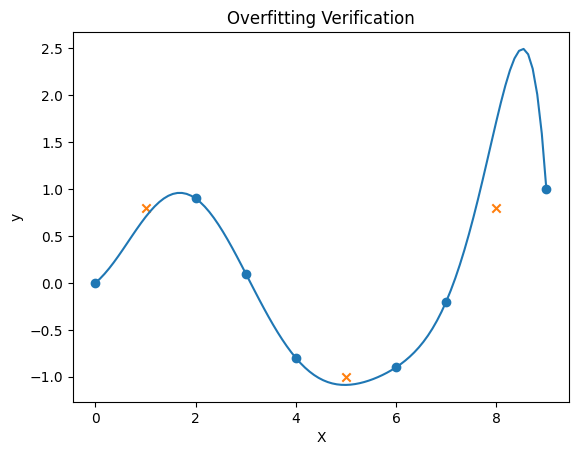

In [22]:
plt.scatter(X_train, y_train, label='Train Data', marker='o')
plt.scatter(X_test, y_test, label='Test Data', marker='x')

# Plot the predicted model curve
X_all = np.linspace(0,9,100).reshape(-1,1)
y_all_pred = model.predict(poly.transform(X_all))
plt.plot(X_all, y_all_pred, label='Model Fit')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Overfitting Verification")
plt.show()